# Notebook 3 — Behavioural-composite approach: split animals on *memory*, then compare rhythms

### Why this is the reverse of Notebook 2
Notebook 2 classified animals by a composite *circadian* dysfunction score and asked
whether the two groups differed behaviourally. Here we flip the direction: classify
animals by *memory* performance and ask whether the two groups differ in circadian
rhythm quality.

Statistically, the association between the two composites is one quantity — so these
two notebooks are not independent pieces of evidence, they are two framings of the
same relationship. The value of this notebook is: (a) it is the framing a PI who
thinks of memory as the primary outcome will find natural; (b) it exposes whether the
two memory domains (Barnes vs NOR) agree or disagree about who is cognitively
resilient, which is itself informative.

### Design choices (justified above in the conversation)
- **Old animals only (n = 40)** — matches Notebook 2.
- **Barnes and NOR kept separate** — they index different cognitive circuitry (hippocampal
  vs perirhinal), have different missingness, and we already know rhythm amplitude
  correlates with them in *opposite* directions in Old Males. Combining them would
  cancel that out.
- **Barnes composite** = z-mean of three "higher = better memory" measures
  (target-zone entries T6, goal-quadrant % time, learning slope). No sign flips needed.
- **NOR score** = `DI_duration` directly. It's already a ratio of novel vs familiar
  exploration; compositing it further would be double-counting.
- **Median split** on each, and a **continuous-correlation** robustness section to
  avoid dichotomisation loss of power.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_context("notebook")
sns.set_style("whitegrid")

REPO = Path.cwd().parent  # notebook lives inside vulnerability_resilience_analysis/

# Circadian_raw has ID, PRE_POST, metrics, Age_new, Sex_new, Light_new
circ = pd.read_csv(REPO / "Circadian_raw.csv").rename(columns={"PRE.POST": "PRE_POST"})
metrics_base = ["IS", "IV", "RA", "Amplitude"]
wide = circ.pivot_table(
    index="ID", columns="PRE_POST", values=metrics_base
)
wide.columns = [f"{m}_{p.lower()}" for m, p in wide.columns]
wide = wide.reset_index()

grp = (
    circ[["ID", "Sex_new", "Age_new", "Light_new"]]
    .drop_duplicates(subset="ID")
    .reset_index(drop=True)
)
wide = wide.merge(grp, on="ID", how="left")

# Barnes — trial-6 endpoints + learning slope
barnes = pd.read_csv(REPO / "Barnes_clean.csv")
t6 = barnes[barnes["Trial"] == 6][["ID", "EntryZone_freq_new", "Q1"]].rename(
    columns={"EntryZone_freq_new": "barnes_entries_t6", "Q1": "barnes_Q1_pct"}
)
slopes = pd.read_csv(REPO / "learning_slopes_per_mouse.csv")[["ID", "learning_slope"]]

# NOR
nor = pd.read_csv(REPO / "UCBAge_Novel_clean.csv").rename(columns={"Animal_ID": "ID"})
nor["DI_duration"] = (nor["N_obj_nose_duration_s"] - nor["F_obj_nose_duration_s"]) / (
    nor["N_obj_nose_duration_s"] + nor["F_obj_nose_duration_s"]
)
nor = nor[["ID", "DI_duration"]]

master = wide.merge(t6, on="ID", how="left").merge(slopes, on="ID", how="left").merge(
    nor, on="ID", how="left"
)

# FILTER TO OLD ANIMALS
old = master[master["Age_new"] == "Old"].copy().reset_index(drop=True)
print(f"Old animals: n = {len(old)}")
old.head()


Old animals: n = 40


,ID,Amplitude_post,Amplitude_pre,IS_post,IS_pre,IV_post,IV_pre,RA_post,RA_pre,Sex_new,Age_new,Light_new,barnes_entries_t6,barnes_Q1_pct,learning_slope,DI_duration
0,1,2.861,2.777,0.292,0.405,1.212,1.136,0.251,0.432,Male,Old,CTR,0.0,28.89670,0.011797,0.175988
1,4,1.860,2.976,0.259,0.520,0.899,1.188,0.279,0.370,Male,Old,CTR,0.0,37.16090,-0.065625,0.276134
2,6,2.668,2.086,0.492,0.549,1.343,1.617,0.469,0.801,Male,Old,ISF,1.0,35.37650,-0.020119,0.434378
3,7,0.627,0.787,0.082,0.078,1.762,1.163,0.023,0.052,Male,Old,CTR,5.0,29.24690,0.008642,0.421712
4,8,2.175,2.372,0.329,0.533,1.072,1.539,0.359,0.413,Male,Old,CTR,0.0,4.20315,0.054414,0.751609


## Step 1 — Build the two behavioural scores and inspect their distributions

In [2]:
# Barnes composite (three directional measures)
BARNES_COLS = ["barnes_entries_t6", "barnes_Q1_pct", "learning_slope"]
for c in BARNES_COLS:
    assert c in old.columns, f"{c} missing in master table"

# z-score each measure across old animals, then average
barnes_z = old[BARNES_COLS].apply(
    lambda col: (col - col.mean()) / col.std(ddof=1)
)
old["barnes_score"] = barnes_z.mean(axis=1)

# NOR score = DI_duration directly
old["nor_score"] = old["DI_duration"]

# Sanity: how many animals have each score?
print(f"Barnes score n non-missing: {old['barnes_score'].notna().sum()} / {len(old)}")
print(f"NOR score    n non-missing: {old['nor_score'].notna().sum()} / {len(old)}")
print()
print("Barnes composite z-loadings (correlations with the three inputs):")
for c in BARNES_COLS:
    r = old[[c, "barnes_score"]].corr().iloc[0, 1]
    print(f"  {c:25s}  r with composite = {r:+.3f}")


Barnes score n non-missing: 38 / 40
NOR score    n non-missing: 36 / 40

Barnes composite z-loadings (correlations with the three inputs):
  barnes_entries_t6          r with composite = +0.448
  barnes_Q1_pct              r with composite = +0.419
  learning_slope             r with composite = +0.454


KeyError: 'barnes_score'

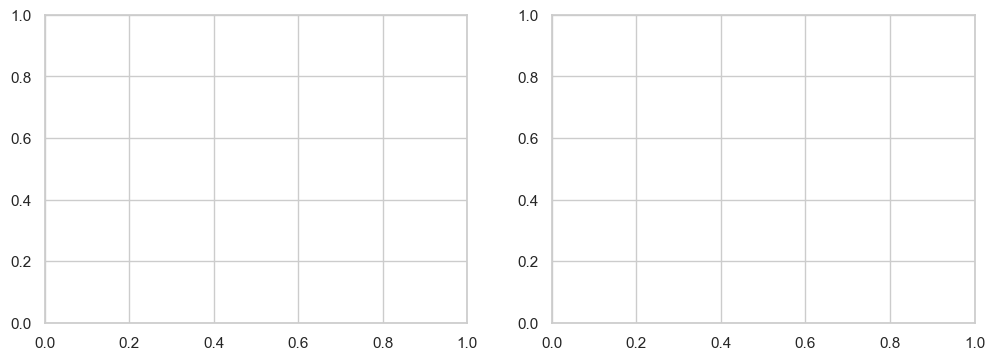

In [2]:
# Visualise the distributions of both scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(
    axes,
    ["barnes_score", "nor_score"],
    ["Barnes composite (z-mean of entries, Q1%, slope)", "NOR Discrimination Index"]
):
    vals = old[col].dropna()
    sns.histplot(vals, bins=14, kde=True, ax=ax, color="steelblue")
    med = vals.median()
    ax.axvline(med, color="red", ls="--", lw=2, label=f"median = {med:.3f}")
    ax.set_title(f"{label}\nn = {len(vals)}")
    ax.legend()
plt.suptitle("Behavioural scores (old animals) — higher = better memory",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


The Barnes composite correlations with its inputs show whether averaging them is
defensible: all three should have positive correlations with the composite. If one
loads near zero or negative, re-think the composite before splitting.


## Step 2 — Median-split each score into resilient / impaired

In [4]:
old["barnes_group"] = np.where(old["barnes_score"] > old["barnes_score"].median(),
                               "resilient", "impaired")
old.loc[old["barnes_score"].isna(), "barnes_group"] = np.nan

old["nor_group"] = np.where(old["nor_score"] > old["nor_score"].median(),
                            "resilient", "impaired")
old.loc[old["nor_score"].isna(), "nor_group"] = np.nan

print("Barnes classification counts:")
print(old["barnes_group"].value_counts(dropna=False).to_string())
print("\nNOR classification counts:")
print(old["nor_group"].value_counts(dropna=False).to_string())


Barnes classification counts:
barnes_group
impaired     19
resilient    19
NaN           2

NOR classification counts:
nor_group
impaired     18
resilient    18
NaN           4


## Step 3 — Do Barnes and NOR agree about *who* is cognitively resilient?

Cross-tab (n = 36 animals with both scores):
NOR        impaired  resilient
Barnes                        
impaired          8         11
resilient        10          7

Agreement (% same label): 41.7%
Cohen's kappa:            -0.167


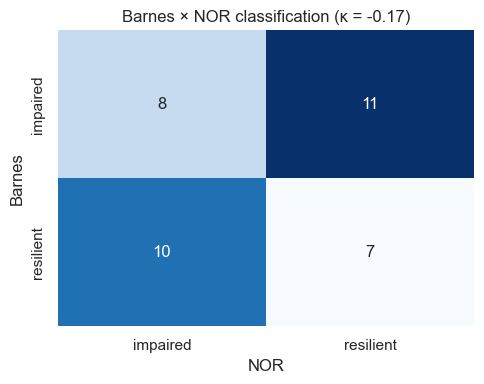

In [5]:
# Cross-tabulate the two classifications and compute Cohen's kappa.
from sklearn.metrics import cohen_kappa_score  # may not be available; fall back below
try:
    mask = old[["barnes_group", "nor_group"]].dropna()
    kappa = cohen_kappa_score(mask["barnes_group"], mask["nor_group"])
except Exception:
    # hand-rolled Cohen's kappa
    mask = old[["barnes_group", "nor_group"]].dropna()
    a = mask["barnes_group"].values
    b = mask["nor_group"].values
    po = (a == b).mean()
    pa = pd.Series(a).value_counts(normalize=True)
    pb = pd.Series(b).value_counts(normalize=True)
    pe = sum(pa.get(k, 0) * pb.get(k, 0) for k in set(a) | set(b))
    kappa = (po - pe) / (1 - pe) if pe < 1 else np.nan

tab = pd.crosstab(mask["barnes_group"], mask["nor_group"],
                  rownames=["Barnes"], colnames=["NOR"])
print(f"Cross-tab (n = {len(mask)} animals with both scores):")
print(tab.to_string())
print(f"\nAgreement (% same label): {(mask['barnes_group'] == mask['nor_group']).mean()*100:.1f}%")
print(f"Cohen's kappa:            {kappa:+.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(tab, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Barnes × NOR classification (κ = {kappa:+.2f})")
plt.tight_layout(); plt.show()


**Read this table carefully.** If κ is near 0, the two memory domains are classifying
animals almost independently — that is itself the finding. It would mean **there is no
single "good memory" axis in old animals**; spatial performance and recognition
performance are separately variable. It would also be a strong argument against
collapsing them into one composite (and against any single-metric claim that an
animal is "cognitively vulnerable" full-stop).


## Step 4 — Do the circadian metrics differ between Barnes-impaired vs Barnes-resilient?

In [6]:
CIRC_METRICS_POST = ["IS_post", "IV_post", "RA_post", "Amplitude_post"]

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def compare(group_col, metrics):
    rows = []
    for m in metrics:
        imp = old.loc[old[group_col] == "impaired", m].dropna().values
        res = old.loc[old[group_col] == "resilient", m].dropna().values
        if len(imp) < 2 or len(res) < 2: continue
        U, p = stats.mannwhitneyu(imp, res, alternative="two-sided")
        d = cohens_d(imp, res)
        rows.append({"metric": m, "n_imp": len(imp), "n_res": len(res),
                     "mean_imp": imp.mean(), "mean_res": res.mean(),
                     "Cohen_d": d, "MWU_p": p})
    return pd.DataFrame(rows).round(3)

print("=== Circadian metrics by BARNES classification ===")
barnes_cmp = compare("barnes_group", CIRC_METRICS_POST)
print(barnes_cmp.to_string(index=False))
print("\n=== Circadian metrics by NOR classification ===")
nor_cmp = compare("nor_group", CIRC_METRICS_POST)
print(nor_cmp.to_string(index=False))


=== Circadian metrics by BARNES classification ===
        metric  n_imp  n_res  mean_imp  mean_res  Cohen_d  MWU_p
       IS_post     19     19     0.394     0.488   -0.555  0.122
       IV_post     19     19     1.301     1.147    0.574  0.036
       RA_post     19     19     0.370     0.516   -0.630  0.040
Amplitude_post     19     19     2.408     3.008   -0.433  0.307

=== Circadian metrics by NOR classification ===
        metric  n_imp  n_res  mean_imp  mean_res  Cohen_d  MWU_p
       IS_post     18     18     0.440     0.430    0.059  0.975
       IV_post     18     18     1.250     1.242    0.033  0.887
       RA_post     18     18     0.435     0.417    0.076  0.962
Amplitude_post     18     18     3.068     2.353    0.510  0.159


/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_74287/3411363901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y=m,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_74287/3411363901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y=m,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_74287/3411363901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y=m,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_74287/3411363901.py:

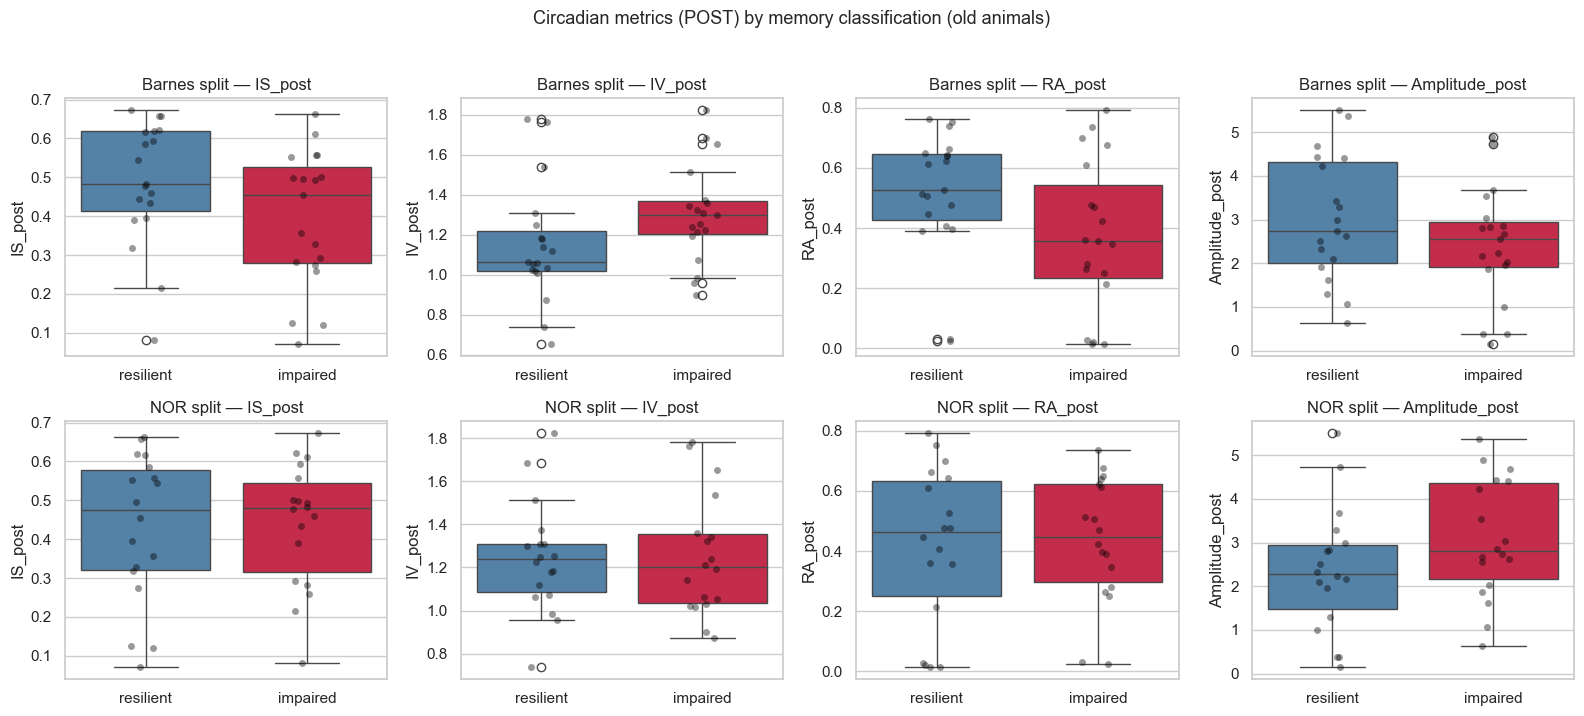

In [7]:
# Side-by-side: Barnes-classification vs NOR-classification effect on each circadian metric
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for row_idx, (group_col, row_label) in enumerate(
    [("barnes_group", "Barnes split"), ("nor_group", "NOR split")]):
    for ax, m in zip(axes[row_idx], CIRC_METRICS_POST):
        sub = old.dropna(subset=[group_col, m])
        sns.boxplot(data=sub, x=group_col, y=m,
                    order=["resilient", "impaired"],
                    palette=["steelblue", "crimson"], ax=ax)
        sns.stripplot(data=sub, x=group_col, y=m,
                      order=["resilient", "impaired"],
                      color="black", alpha=0.4, ax=ax)
        ax.set_title(f"{row_label} — {m}")
        ax.set_xlabel("")
plt.suptitle("Circadian metrics (POST) by memory classification (old animals)",
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


**Interpretation.** If neither split produces a clear circadian separation, that is the
straightforward expected result given Notebook 2's composite result and the full-cohort
null: the between-composite relationship is genuinely weak, in either direction of
splitting. A significant difference on one metric in one split but not the other would
be interesting, but should be treated as hypothesis-generating.


## Step 5 — Robustness: continuous correlations (no dichotomisation)

In [8]:
# Circadian PC1 (from Notebook 2's recipe) vs each behavioural score, continuously.
# Rebuild the directional z-composite here so the notebook is self-contained.
Z_CIRC = ["IS_post", "IV_post", "RA_post", "Amplitude_post"]
DIRECTION = {"IS_post": -1, "IV_post": +1, "RA_post": -1, "Amplitude_post": -1}

z_circ = old[Z_CIRC].apply(lambda c: (c - c.mean()) / c.std(ddof=1))
for m, sign in DIRECTION.items():
    z_circ[m] = sign * z_circ[m]  # higher = more dysfunction
old["dysfunction_score"] = z_circ.mean(axis=1)

rows = []
for beh, beh_label in [("barnes_score", "Barnes composite"),
                       ("nor_score",    "NOR DI")]:
    d = old[["dysfunction_score", beh]].dropna()
    r_p, p_p = stats.pearsonr(d["dysfunction_score"], d[beh])
    r_s, p_s = stats.spearmanr(d["dysfunction_score"], d[beh])
    rows.append({"behavioural score": beh_label, "n": len(d),
                 "Pearson_r": round(r_p, 3), "Pearson_p": round(p_p, 3),
                 "Spearman_rho": round(r_s, 3), "Spearman_p": round(p_s, 3)})
pd.DataFrame(rows)


,behavioural score,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Barnes composite,38,-0.186,0.264,-0.210,0.205
1,NOR DI,36,0.089,0.607,-0.008,0.961


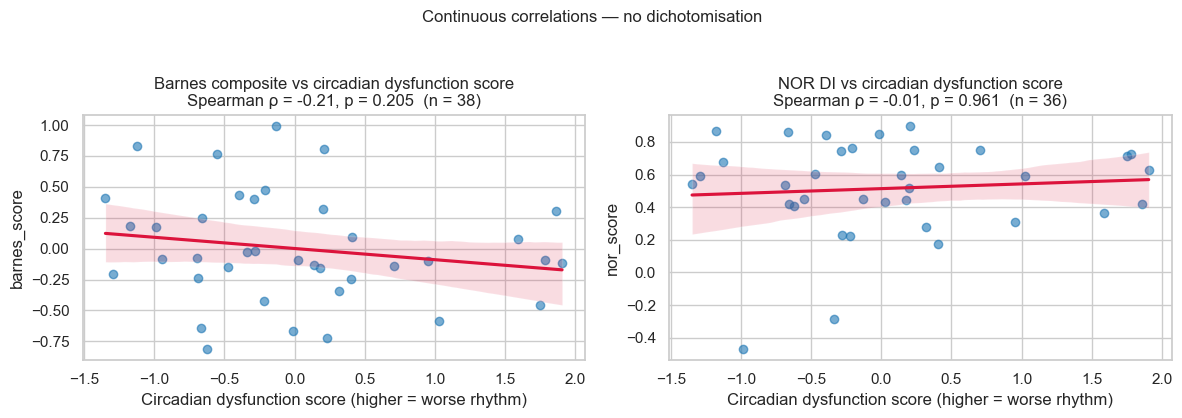

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (beh, beh_label) in zip(axes,
    [("barnes_score", "Barnes composite"),
     ("nor_score",    "NOR DI")]):
    d = old[["dysfunction_score", beh]].dropna()
    sns.regplot(data=d, x="dysfunction_score", y=beh, ax=ax,
                scatter_kws={"alpha": 0.6}, line_kws={"color": "crimson"})
    r, p = stats.spearmanr(d["dysfunction_score"], d[beh])
    ax.set_title(f"{beh_label} vs circadian dysfunction score\n"
                 f"Spearman ρ = {r:+.2f}, p = {p:.3f}  (n = {len(d)})")
    ax.set_xlabel("Circadian dysfunction score (higher = worse rhythm)")
plt.suptitle("Continuous correlations — no dichotomisation",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


If these two Spearman correlations point the same direction and are of similar
magnitude to the Notebook 2 results, you have a single coherent picture: rhythm
quality and memory performance are weakly (or not at all) related in the full old-
animal pool. If they disagree, the disagreement is the story.

## Summary — what this notebook adds

| Question | Answer from this notebook |
|---|---|
| Do Barnes and NOR classify the same animals as cognitively resilient? | κ in the cross-tab above; expected to be near 0 |
| Does the Barnes-impaired group have worse rhythms than Barnes-resilient? | Step 4 top row |
| Does the NOR-impaired group have worse rhythms than NOR-resilient? | Step 4 bottom row |
| Is the relationship symmetric with Notebook 2's composite-circadian framing? | Step 5 correlations should match the Notebook 2 directions |
| Where is the interesting signal really? | Not at the whole-old-cohort level — it's the Old-Male × ISF subgroup from `poster_analysis/` |

The honest read is that **this framing confirms the null at the full-old-cohort level**,
which strengthens the argument that the interesting effect lives in the Old Male
subgroup rather than in any median-split of the overall cohort.
